## Examples for how to work with AIGD-PFT data on Abyssio

In [1]:
# %% Libraries
library(getPass)
library(ncdf4)

# %% Functions
get_app_config_dir <- function(appname) {
  app_rel_path <- file.path(".config", appname, paste0(appname, ".conf"))
  app_system_path <- file.path(path.expand("~"), app_rel_path)
  return(app_system_path)
}

# %% Env Var
appname            <- "oceananalysis"
server_config_name <- "default"


In [2]:
library(aws.s3)
library(ini)

# %% Main
app_system_path <- get_app_config_dir(appname = appname)
config          <- read.ini(app_system_path)

# Set credentials as environment variables (used by aws.s3 internally)
Sys.setenv(
  "AWS_ACCESS_KEY_ID"     = trimws(config[[server_config_name]][["access_key"]]),
  "AWS_SECRET_ACCESS_KEY" = trimws(config[[server_config_name]][["secret_key"]]),
  "AWS_S3_ENDPOINT" = trimws(config[[server_config_name]][["endpoint"]]))
options("cloudyr.aws.default_region" = "")
buckets <- bucketlist(use_https=F)
cat(buckets$Bucket, sep = "\n")
     

input
personal
test


## Setting your connection to Abyssio

In [3]:
# Read configuration
app_system_path <- get_app_config_dir(appname = appname)
config          <- read.ini(app_system_path)

# Set credentials as environment variables (used by aws.s3 internally)
Sys.setenv(
  "AWS_ACCESS_KEY_ID"     = trimws(config[[server_config_name]][["access_key"]]),
  "AWS_SECRET_ACCESS_KEY" = trimws(config[[server_config_name]][["secret_key"]]),
  "AWS_S3_ENDPOINT" = trimws(config[[server_config_name]][["endpoint"]]))
options("cloudyr.aws.default_region" = "")

## Downloading a single AIGD-PFT file

In [4]:
# Downloading a single file

# %% Env var
# Server location information
bucket_name <- "input"
prefix      <- "AIGD-PFT/regridded_jra"            #--- specify the folder name here
file_name   <- "AIGD_PFT_2000_totChl_JRA_mesh.nc"  #--- specify the file name here 
object_name <- paste(prefix, file_name, sep = "/")

# Local location information
local_download_directory <- "downloads"
local_download_path      <- file.path(path.expand("~"), local_download_directory)
local_file_path          <- file.path(local_download_path, file_name)

dir.create(local_download_path, recursive = TRUE, showWarnings = FALSE)

# %% Main
# Downloading the file and save it in variable 'file'
file = save_object(
  object   = object_name,
  bucket   = bucket_name,
  file     = local_file_path,
  use_https = F
)

## working with the netcdf file

In [5]:
#---
# step 1: get some info about what's in the file
#---

# open netcdf file
nc <- nc_open(file)

# print information contained in netcdf file
print(nc)

# print all variables contained in file 
print('List of all variables file:')
names(nc$var)
print('List of all dimensions file:')
names(nc$dim)

#---
# working with the netcdf file
# step 2: load a variable you want to plot
#---

# load total chlorophyll and lat/lon information
totchl <- ncvar_get(nc, "totChl")
lat <- ncvar_get(nc, "lat")
lon <- ncvar_get(nc, "lon")
str(lat)
str(lon)
str(totchl) # comparison with size of lat/lon arrays reveals totchl is stored as lon x lat x time
# looking at the output of str() also tells you that totchl array contains NAs (over land and where data is missing)

# what if you only want to read a subset of the data?
totchl_slice <- ncvar_get(nc,
                        "totChl",
                        start = c(1, 1, 1),
                        count = c(-1, -1, 1)) # read in all entries for 1st and 2nd dimension, only the first entry for last dimension
str(totchl_slice) # compare to totchl above

# print some information
print(paste(c('minimum of longitude:',min(lon,na.rm=TRUE))))
print(paste(c('maximum of longitude:',max(lon,na.rm=TRUE))))
print(paste(c('minimum of latitude:',min(lat,na.rm=TRUE))))
print(paste(c('maximum of latitude:',max(lat,na.rm=TRUE))))

print(paste(c('minimum of totchl:',min(totchl,na.rm=TRUE))))
print(paste(c('maximum of totchl:',max(totchl,na.rm=TRUE))))

# Transpose and flip if needed
#totchl <- t(totchl)             # transpose
#lon    <- rev(lon)                  # reverse lon
#totchl <- totchl[length(lon):1,]  # reorder rows
#totchl <- rbind(totchl[321:640, ], totchl[1:320, ])


# close the netcdf file (important!)
nc_close(nc)


File /home/cnissen/downloads/AIGD_PFT_2000_totChl_JRA_mesh.nc (NC_FORMAT_NETCDF4_CLASSIC):

     2 variables (excluding dimension variables):
        float totChl[lon,lat,Time]   (Contiguous storage)  
            _FillValue: -999
            description: total chlorophyll (added all eight PFTs)
            unit: mg chl m-3
        float time[Time]   (Contiguous storage)  
            _FillValue: -999
            units: days since 1979-01-01 00:00:00
            calendar: noleap

     3 dimensions:
        lon  Size:640 
            _FillValue: -999
            description: Longitude (-180:180)
            unit: deg E
        lat  Size:320 
            _FillValue: -999
            description: Latitude
            unit: deg N
        Time  Size:365 (no dimvar)

    3 global attributes:
        contact: Cara Nissen, c.nissen@uva.nl
        source_file: /global/cfs/cdirs/m4839/cnissen/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Prok_JRA_mesh.nc
        script: /global/homes/c/cnissen/scripts/sa

[1] "totChl" "time"

[1] "List of all dimensions file:"


[1] "lon"  "lat"  "Time"

 num [1:320(1d)] -89.6 -89 -88.5 -87.9 -87.3 ...
 num [1:640(1d)] -179 -179 -178 -178 -177 ...
 num [1:640, 1:320, 1:365] NA NA NA NA NA NA NA NA NA NA ...
 num [1:640, 1:320] NA NA NA NA NA NA NA NA NA NA ...
[1] "minimum of longitude:" "-179.4375"            
[1] "maximum of longitude:" "180"                  
[1] "minimum of latitude:" "-89.5700912475586"   
[1] "maximum of latitude:" "89.5700912475586"    
[1] "minimum of totchl:"  "0.00639317696914077"
[1] "maximum of totchl:" "298.675506591797"  


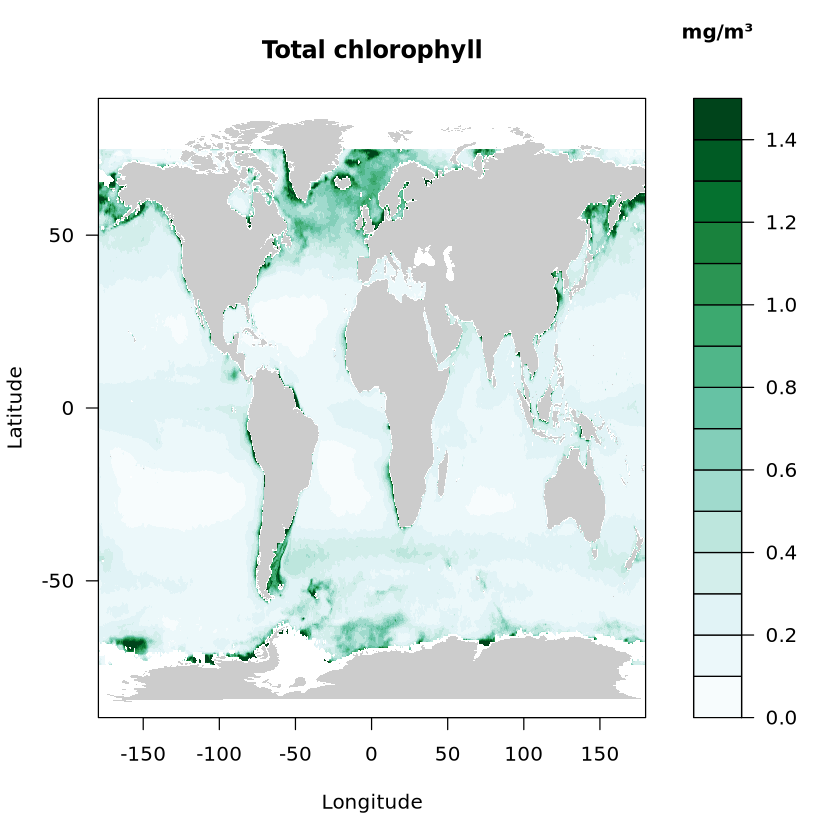

In [6]:
#---
# plot a global map
#---
library(maps)  # for coastlines
library(RColorBrewer) # for more options for color palette

# for plotting a map, you need to ensure the data only contains lon x lat (i.e., no time)
# options: plot a single time step of the data or average all time steps here
totchl_plot <- apply(totchl, c(1,2), mean, na.rm = TRUE) # average over the 3rd dimension, i.e., all time steps in file

# Define manual color limits
zmin <- 0       # minimum value for color scale
zmax <- 1.5     # maximum value for color scale
ncolors <- 100  # number of colors of the colorbar
#cols <- terrain.colors(ncolors)   # color palette
cols   <- brewer.pal(9, "BuGn") # ask ChatGPT for options :)
breaks <- seq(zmin, zmax, length.out = ncolors + 1)

# these lines of code ensure that values above the chosen zmax (or below zmin) are plotted correctly
# Example: if the true max of the data exceeds zmax chosen above, these areas appear white in the plot
totchl_clipped <- totchl_plot
totchl_clipped[totchl_clipped > zmax] <- zmax
totchl_clipped[totchl_clipped < zmin] <- zmin

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
#png("global_map.png", width = 1600, height = 900, res = 150)  # width x height in pixels

filled.contour(lon, lat, totchl_clipped,
               color.palette = function(n) colorRampPalette(brewer.pal(9, "BuGn"))(n),
               xlab="Longitude", ylab="Latitude",main = "Total chlorophyll",zlim = c(zmin,zmax),
               key.title = title(main = "mg/m³", line = 2.5, cex.main = 1, srt = 270),
                plot.axes = {
                axis(1); axis(2)            # optional: redraw axes
                map("world", add = TRUE, fill = TRUE, col = "grey80", border = NA)})  # correct placement)

# uncomment if you want to save the figure
#dev.off()  # close the device

# an alternative way to plotting:
#image(lon, lat, totchl,
#      col = cols,
#      zlim = c(0, 1.5),
#      xlab = "Longitude",
#      ylab = "Latitude")
#map("world", add = TRUE, fill = TRUE, col = "grey80", border = NA)


Warning message:
“`borders()` was deprecated in ggplot2 4.0.0.
ℹ Please use `annotation_borders()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


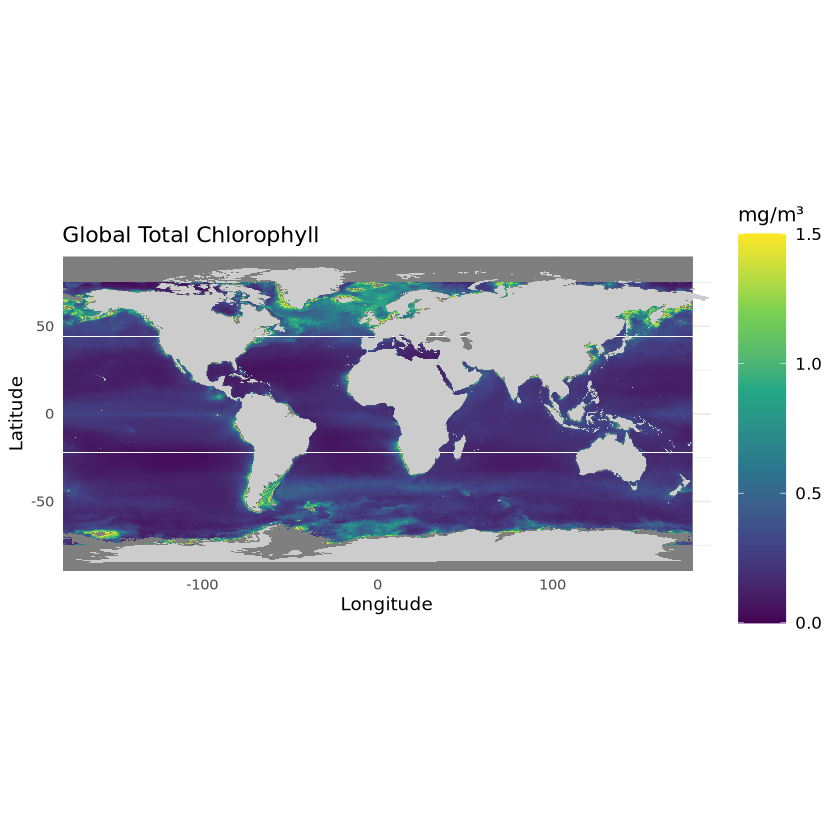

In [7]:
#---
# plot a global map differently
#---
library(ggplot2)
library(reshape2)  # or use tidyr

# for plotting a map, you need to ensure the data only contains lon x lat (i.e., no time)
# options: plot a single time step of the data or average all time steps here
totchl_plot <- apply(totchl, c(1,2), mean, na.rm = TRUE) # average over the 3rd dimension, i.e., all time steps in file

# Prepare data frame
df <- expand.grid(lon = lon, lat = lat)
df$totchl <- as.vector(totchl_plot)  # flatten

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
#png("global_map2.png", width = 1600, height = 900, res = 150)  # width x height in pixels

# Plot
ggplot(df, aes(x = lon, y = lat, fill = totchl)) +
  geom_raster(interpolate = FALSE) +
  scale_fill_viridis_c(name = "mg/m³", limits = c(zmin, zmax)) +
  borders("world", fill = "grey80", colour = NA) +
  coord_fixed(expand = FALSE) +
  labs(x = "Longitude", y = "Latitude", title = "Global Total Chlorophyll") +
  theme_minimal() +
  theme(
    legend.key.height = unit(0.65, "inches"),  # increase vertical size
    legend.key.width  = unit(0.4, "inches"), # optional: adjust width
    legend.title     = element_text(size = 12),  # bigger title font
    legend.text      = element_text(size = 10)   # bigger tick labels
  )

# uncomment if you want to save the figure
#dev.off()  # close the device


In [8]:
#---
# plot only a specific region
# EXAMPLE 1: North Atlantic
#---

# for plotting a map, you need to ensure the data only contains lon x lat (i.e., no time)
# options: plot a single time step of the data or average all time steps here
totchl_plot <- apply(totchl, c(1,2), mean, na.rm = TRUE) # average over the 3rd dimension, i.e., all time steps in file

# define region and find lat/lon indices
lon_min <- -60 # western limit
lon_max <- 20 # eastern limit
lat_min <- 45 # southern limit
lat_max <- 75 # northern limit
lon_idx <- which(lon >= lon_min & lon <= lon_max)
lat_idx <- which(lat >= lat_min & lat <= lat_max)

# subset the data to plot
lon_sub <- lon[lon_idx]
lat_sub <- lat[lat_idx]
data_sub <- totchl_plot[lon_idx, lat_idx]

# Define manual color limits
zmin <- 0       # minimum value for color scale
zmax <- 1.5     # maximum value for color scale
ncolors <- 100  # number of colors of the colorbar
#cols <- terrain.colors(ncolors)   # color palette
cols   <- brewer.pal(9, "BuGn") # ask ChatGPT for options :)
breaks <- seq(zmin, zmax, length.out = ncolors + 1)

# these lines of code ensure that values above the chosen zmax (or below zmin) are plotted correctly
# Example: if the true max of the data exceeds zmax chosen above, these areas appear white in the plot
totchl_clipped <- totchl_plot
totchl_clipped[totchl_clipped > zmax] <- zmax
totchl_clipped[totchl_clipped < zmin] <- zmin

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
png("NorthAtlantic_map.png", width = 1600, height = 900, res = 150)  # width x height in pixels

filled.contour(lon_sub, lat_sub, data_sub,
  color.palette = function(n) colorRampPalette(brewer.pal(9, "BuGn"))(n),
  xlab = "Longitude",
  ylab = "Latitude",
  main = "Total chlorophyll",
  zlim = c(zmin, zmax),
  key.title = title(main = "mg/m³", line = 2.5, cex.main = 1, srt = 270),
  plot.axes = {
    axis(1); axis(2)
    map("world",
        xlim = c(lon_min, lon_max),
        ylim = c(lat_min, lat_max),
        add = TRUE,
        fill = TRUE,
        col = "grey80",
        border = NA)
  })

# uncomment if you want to save the figure
dev.off()  # close the device



agg_record_b27e21a46f7d 
                      2

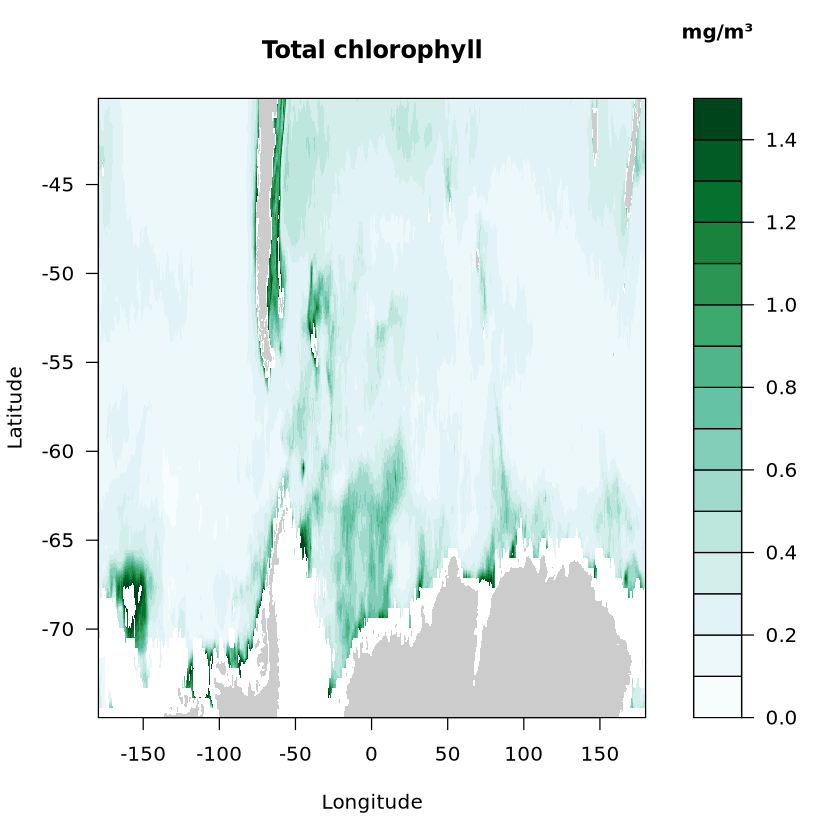

In [9]:
#---
# plot only a specific region
# EXAMPLE 2: Southern Ocean
#---

# for plotting a map, you need to ensure the data only contains lon x lat (i.e., no time)
# options: plot a single time step of the data or average all time steps here
totchl_plot <- apply(totchl, c(1,2), mean, na.rm = TRUE) # average over the 3rd dimension, i.e., all time steps in file

# define region and find lat/lon indices
lon_min <- -180 # western limit
lon_max <- 180 # eastern limit
lat_min <- -75 # southern limit
lat_max <- -40 # northern limit
lon_idx <- which(lon >= lon_min & lon <= lon_max)
lat_idx <- which(lat >= lat_min & lat <= lat_max)

# subset the data to plot
lon_sub <- lon[lon_idx]
lat_sub <- lat[lat_idx]
data_sub <- totchl_plot[lon_idx, lat_idx]

# Define manual color limits
zmin <- 0       # minimum value for color scale
zmax <- 1.5     # maximum value for color scale
ncolors <- 100  # number of colors of the colorbar
#cols <- terrain.colors(ncolors)   # color palette
cols   <- brewer.pal(9, "BuGn") # ask ChatGPT for options :)
breaks <- seq(zmin, zmax, length.out = ncolors + 1)

# these lines of code ensure that values above the chosen zmax (or below zmin) are plotted correctly
# Example: if the true max of the data exceeds zmax chosen above, these areas appear white in the plot
totchl_clipped <- totchl_plot
totchl_clipped[totchl_clipped > zmax] <- zmax
totchl_clipped[totchl_clipped < zmin] <- zmin

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
#png("SouthernOcean_map.png", width = 1600, height = 900, res = 150)  # width x height in pixels

filled.contour(lon_sub, lat_sub, data_sub,
  color.palette = function(n) colorRampPalette(brewer.pal(9, "BuGn"))(n),
  xlab = "Longitude",
  ylab = "Latitude",
  main = "Total chlorophyll",
  zlim = c(zmin, zmax),
  key.title = title(main = "mg/m³", line = 2.5, cex.main = 1, srt = 270),
  plot.axes = {
    axis(1); axis(2)
    map("world",
        xlim = c(lon_min, lon_max),
        ylim = c(lat_min, lat_max),
        add = TRUE,
        fill = TRUE,
        col = "grey80",
        border = NA)
  })

# uncomment if you want to save the figure
#dev.off()  # close the device



[1] -20.25
[1] 45.21054


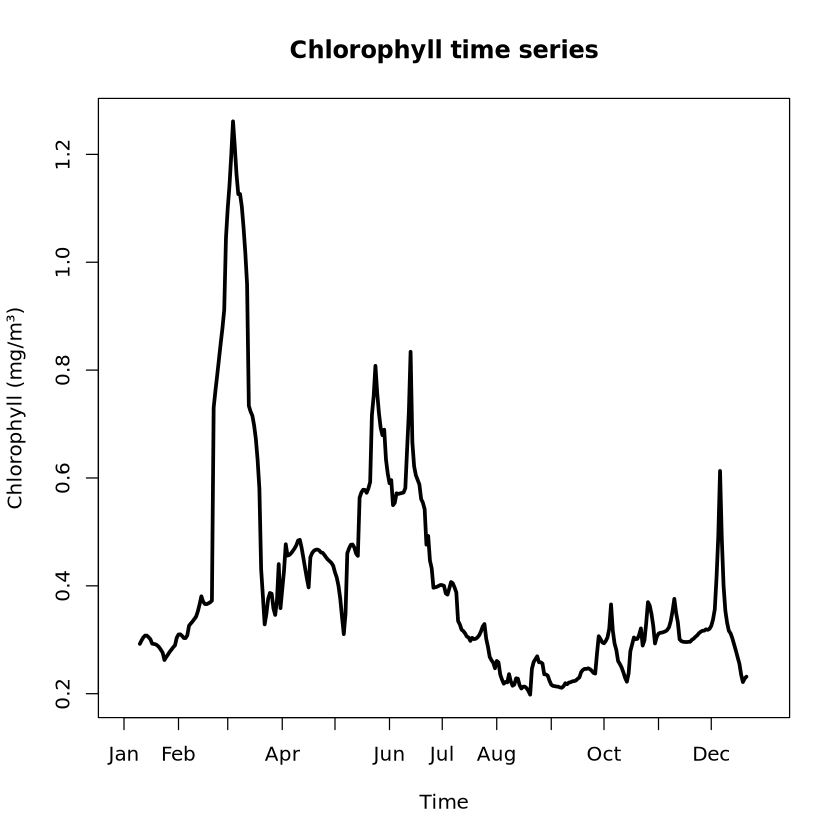

In [10]:
#---
# plot a time series at a specific location
#---

# for plotting a map, you need to ensure the data only contains lon x lat (i.e., no time)
# options: plot a single time step of the data or average all time steps here
#totchl_plot <- apply(totchl, c(1,2), mean, na.rm = TRUE) # average over the 3rd dimension, i.e., all time steps in file

# define location and find lat/lon indices closest to that location
lon_pos <- -20
lat_pos <- 45 
lon_idx <- which.min(abs(lon - lon_pos))
lat_idx <- which.min(abs(lat - lat_pos))
# check
print(lon[lon_idx])
print(lat[lat_idx])

# subset the data to plot
lon_sub <- lon[lon_idx]
lat_sub <- lat[lat_idx]
data_sub <- totchl[lon_idx, lat_idx,] # Note that I am choosing the array totchl here, i.e., the one that contains all 
                                      # time steps of the loaded year

month_days <- c(1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335)
month_labels <- c("Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec")

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
#png("NorthAtlantic_timeSeries.png", width = 1600, height = 900, res = 150)  # width x height in pixels

plot(1:365, data_sub,
     type = "l",
     lwd = 3,
     xaxt="n", # xaxt="n" suppresses the default axis
     xlab = "Time",
     ylab = "Chlorophyll (mg/m³)",
     main = "Chlorophyll time series")
axis(1, at=month_days, labels=month_labels) 

# uncomment if you want to save the figure
#dev.off()  # close the device


## Load multiple files 

In [ ]:
#-----
# possible applications: 
# EXAMPLE 1: plot the average phytoplankton community structure for a given year (or multiple years) at a chosen location
# EXAMPLE 2: plot a time series of a given variable over multiple years at a chosen location
#-----

In [11]:
#-----
# Define a folder, all files in that folder will be screened for a string in the filename
# dowload the selected files
#-----
# EXAMPLE 1: load all phytoplankton types for a chosen year

# %% Env var
# Server location information
bucket_name <- "input"
prefix      <- "AIGD-PFT/regridded_jra/"  # Trailing slash to look into prefix

# define two conditions for data selection
# all files containing this string will be loaded
string_for_selection = "PFT_2000" #"2000_Hapt" 
# all files containing this string will NOT be laoded
string_to_exclude    = "totChl"

# Local location information
local_download_directory <- "downloads"
local_download_path      <- file.path(path.expand("~"), local_download_directory)

dir.create(local_download_path, recursive = TRUE, showWarnings = FALSE)

# %% Main
stime <- as.numeric(Sys.time())  # Seconds since Unix epoch

# List objects in prefix (non-recursive)
objects <- get_bucket(
  bucket    = bucket_name,
  prefix    = prefix,
  delimiter = "/",  # delimiter prevents recursion, equivalent to recursive = False,
  use_https = F
)

# Track stats
nobjs            <- 0

# Download the objects, collect file names in a list
file_list <- c()  # empty vector to store file names
for (obj in objects) {
  object_name     <- obj[["Key"]]

  # Skip some files (see selection strings defined above and how they are used here)
  if (!grepl(string_for_selection, object_name) || grepl(string_to_exclude, object_name)) next
    
  local_file_path <- file.path(local_download_path, object_name) #---- this is where the files will be stored
  print(paste("Downloaded file", file.path(local_download_path, object_name)))

  # Track downloaded files
  file_list <- c(file_list, local_file_path)
    
  # Ensure subdirectory exists
  dir.create(dirname(local_file_path), recursive = TRUE, showWarnings = FALSE)

  file <- save_object(
    object   = object_name,
    bucket   = bucket_name,
    file     = local_file_path,
    use_https = F
  )

  nobjs            <- nobjs + 1
}
print(paste(c('Downloaded number of files:',nobjs)))
 

[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Cryp_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Diat_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Dino_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Gree_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Hapt_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Pela_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Proc_JRA_mesh.nc"
[1] "Downloaded file /home/cnissen/downloads/AIGD-PFT/regridded_jra/AIGD_PFT_2000_Prok_JRA_mesh.nc"
[1] "Downloaded number of files:" "8"                          


[1] -20.25
[1] -0.2808109
            DJF        MAM        JJA        SON
PFT1 0.01174587 0.01575751 0.02999116 0.01773004
PFT2 0.04748276 0.05634719 0.06015963 0.04494806
PFT3 0.03478073 0.04582130 0.05505909 0.03336649
PFT4 0.19330085 0.17882217 0.25230859 0.22643830
PFT5 0.13325296 0.14473193 0.20371290 0.14274609
PFT6 0.02799924 0.02297999 0.03991318 0.02604199
PFT7 0.27852476 0.26647864 0.17357079 0.27256192
PFT8 0.27291282 0.26906127 0.18528465 0.23616710


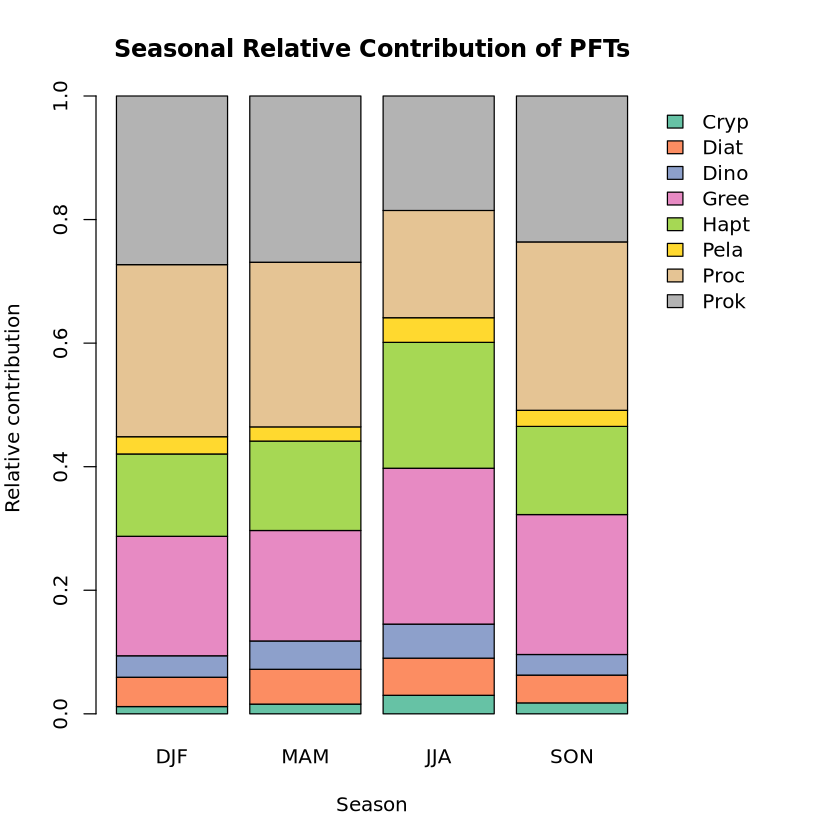

In [12]:
#---
# load chlorophyll associated with each PFT at a certain location
#---

# define location and find lat/lon indices closest to that location
lon_pos <- -20
lat_pos <- 0 #---- vary latitude to see what changes!
lon_idx <- which.min(abs(lon - lon_pos))
lat_idx <- which.min(abs(lat - lat_pos))
# check
print(lon[lon_idx])
print(lat[lat_idx])

# manually define the variable names in the files that you want to load
# Note in the list of downloaded files printed above that the files are sorted alphabetically
vari_list = c("Cryp","Diat","Dino","Gree","Hapt","Pela","Proc","Prok")

# define array (matrix) that will collect chlorophyll of each PFT
chl_PFT <- matrix(NA, nrow = 8, ncol = 365) # 8 PFTs, 365 days

# open netcdf files and extract PFT chlorophyll at selected location
for (ff in 1:length(file_list)) {
    
    nc <- nc_open(file_list[ff])
    #print(file_list[ff])
    #print(vari_list[ff])
    chl_slice <- ncvar_get(nc,vari_list[ff],
                      start = c(lon_idx, lat_idx, 1),   # start at lon_idx (dim1=lon), lat_idx (dim2=lat), 1 (time)
                      count = c(1, 1, -1))       # read 1 element along the first two dimensions and all elements along the third (=all time steps)

    # store result 
    chl_PFT[ff,] <- chl_slice
    
    # close the netcdf file (important!)
    nc_close(nc)

# close for loop
}

# get community structure for each season
days <- 1:365
# define inidices of each season 
seasons <- list(
  DJF = c(1:90, 355:365),
  MAM = 91:181,
  JJA = 182:273,
  SON = 274:354
)
# total chlorophyll
total_chl_daily <- colSums(chl_PFT, na.rm = TRUE)  # sum over PFTs

# get relative contribution of each PFT to total chlorine for each day
rel_chl_daily <- chl_PFT / matrix(total_chl_daily, nrow = 8, ncol = 365, byrow = TRUE)

# aggregate by season
rel_chl_season <- matrix(NA, nrow = 8, ncol = length(seasons))
colnames(rel_chl_season) <- names(seasons)
rownames(rel_chl_season) <- paste0("PFT", 1:8)

for (s in seq_along(seasons)) {
  days_in_season <- seasons[[s]]
  rel_chl_season[, s] <- rowMeans(rel_chl_daily[, days_in_season, drop = FALSE], na.rm = TRUE)
}

print(rel_chl_season)

# Set colors for 8 PFTs
library(RColorBrewer)
pft_colors <- brewer.pal(8, "Set2")  # 8 distinct colors

# if you want to save the figure, uncomment the png() command and the line with dev.off()
# provide figure size and filename (optional: path where to store the file)
#png("NorthAtlantic_barPlot.png", width = 1600, height = 900, res = 150)  # width x height in pixels

# Increase right margin to make space for legend
par(mar = c(5, 4, 4, 8))  # bottom, left, top, right

# Stacked bar plot
barplot(rel_chl_season,
        beside = FALSE,      # stacked bars
        col = pft_colors,
        #legend.text = vari_list,
        #args.legend = list(x = "topright", bty = "n"),
        ylab = "Relative contribution",
        xlab = "Season",
        main = "Seasonal Relative Contribution of PFTs")

# Place legend to the right of the plot
legend(x = par("usr")[2],  # x = right edge of plot + small offset
       y = 1,                     # y = top of plot
       legend = vari_list,
       fill = pft_colors,
       xpd = TRUE,
       bty = "n")

# uncomment if you want to save the figure
#dev.off()  # close the device

#plot(1:365, chl_slice,
#     type = "l",
#     lwd = 3,
#     xaxt="n", # xaxt="n" suppresses the default axis
#     xlab = "Time",
#     ylab = "Chlorophyll (mg/m³)",
#     main = "Chlorophyll time series")
#axis(1, at=month_days, labels=month_labels) 



In [ ]:
# Can you come up with the code for example 2?

In [ ]:
# Upload a single test file
testfile_path <- file.path(path.expand("~"), "plotting_AIGD_PFT_data.ipynb")
#writeLines("Hello World.", testfile_path)  # Uncomment to create the test file

bucket_name <- "input"
prefix      <- "AIGD-PFT/analysis"
access_key  <- trimws(config[[server_config_name]][["access_key"]])
object_name <- paste(access_key, prefix, basename(testfile_path), sep = "/")

put_object(
  file     = testfile_path,
  object   = object_name,
  bucket   = bucket_name,
  use_https = F
)